In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Ex05
Сделай всё необходимое, чтобы получить график как на примере:
- Используй данные из файла: прочитай в DataFrame и при необходимости выполни преобразования.
- Размер фигуры — прежний; размер шрифта выбери сам.
- Палитра — как в примере.
- Размер шрифта заголовка — 15.
- Толщина линий «ящиков» — 3, толщина линий медианы — 2.
- В конце блокнота добавь markdown-ячейку с вопросом: «Каков IQR (межквартильный размах) контрольной группы до появления ленты новостей?» В ответе укажи приблизительное значение, округлив до ближайшего десятка.

In [2]:
df = pd.read_csv('../data/ab-test.csv')

df.head(1)

,uid,diff,time,group
0,user_1,-103.333333,after,test


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uid     44 non-null     str    
 1   diff    44 non-null     float64
 2   time    44 non-null     str    
 3   group   44 non-null     str    
dtypes: float64(1), str(3)
memory usage: 1.5 KB


In [4]:
df['time'] = pd.Categorical(
    df['time'],
    categories=['after', 'before']
)

df['group'] = pd.Categorical(
    df['group'],
    categories=['control', 'test'],
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   uid     44 non-null     str     
 1   diff    44 non-null     float64 
 2   time    44 non-null     category
 3   group   44 non-null     category
dtypes: category(2), float64(1), str(1)
memory usage: 1.1 KB


In [5]:
df_grouped = df.groupby('group')

test = df_grouped.get_group('test')
control = df_grouped.get_group('control')

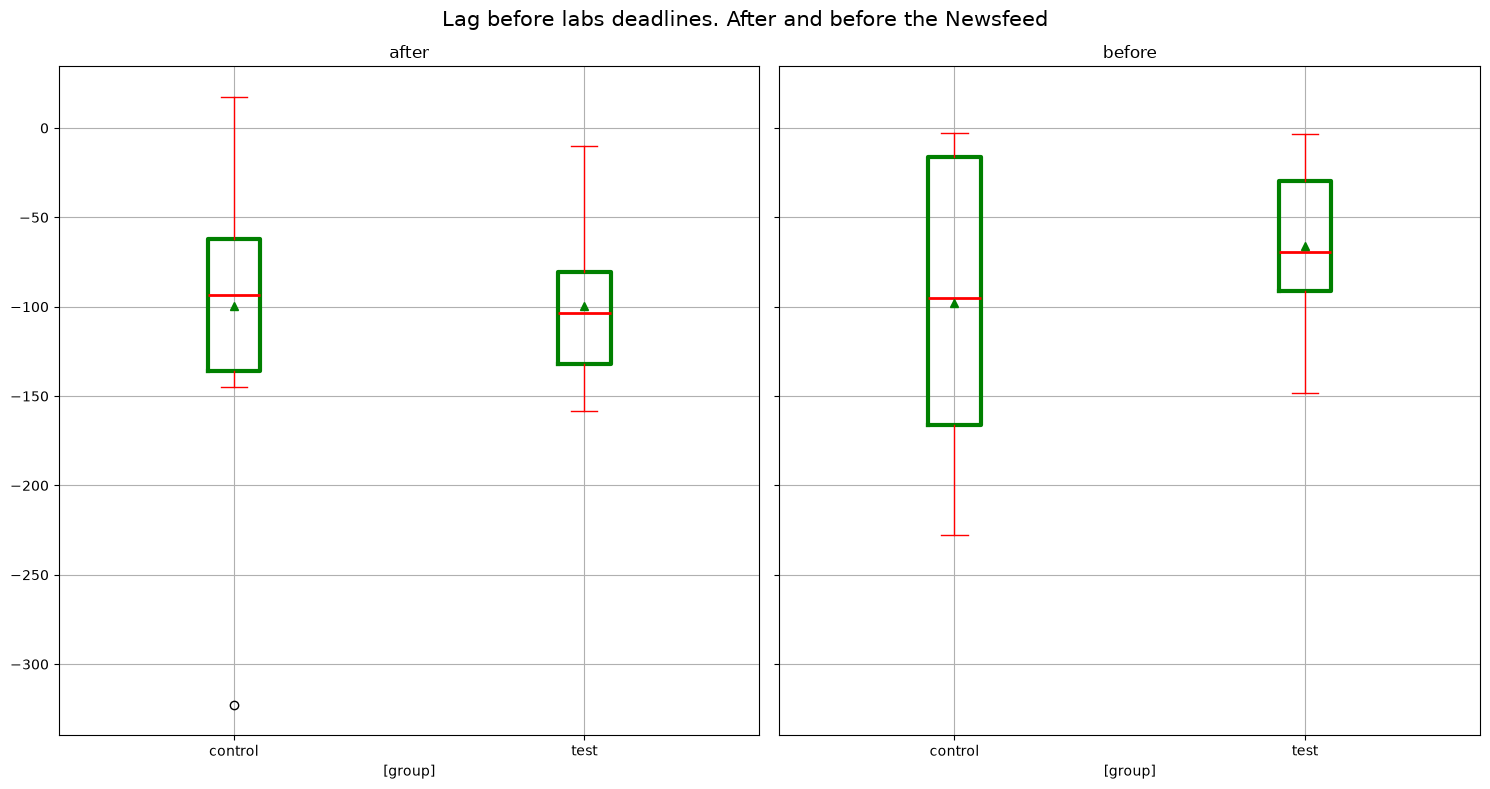

In [6]:
boxplot_kwargs = dict(
    whiskerprops=dict(color='red'),
    capprops=dict(color='red'),
    boxprops=dict(color='green', linewidth=3),
    medianprops=dict(color='red', linewidth=2),
    showmeans=True,
    meanprops=dict(marker='^', markerfacecolor='green', markeredgecolor='green'),
)
 
fig, ax = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
 
for axis, t in zip(ax, ['after', 'before']):
    sub = df[df['time'] == t]
    data = [sub[sub['group'] == g]['diff'] for g in ['control', 'test']]
 
    axis.boxplot(data, **boxplot_kwargs)
    axis.set_title(t)
    axis.set_xticks([1, 2])
    axis.set_xticklabels(['control', 'test'])
    axis.set_xlabel('[group]')
    axis.grid(axis='both')
    axis.set_axisbelow(True)
 
fig.suptitle('Lag before labs deadlines. After and before the Newsfeed', fontsize=15)
plt.tight_layout()
plt.show()

Каков IQR (межквартильный размах) контрольной группы до появления ленты новостей?

In [7]:
control_before = df[(df['group'] == 'control') & (df['time'] == 'before')]['diff']

q1 = control_before.quantile(0.25)
q3 = control_before.quantile(0.75)
iqr = q3 - q1
print(f'IQR: {iqr}')

IQR: 150.0
